In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
sns.set_style("white")

In [2]:
con = duckdb.connect()
con.sql("""
CREATE OR REPLACE TABLE user_activity AS
SELECT *
FROM read_csv_auto('../ressources/user_activity.csv')
""")
con.sql("""
CREATE OR REPLACE TABLE progression AS
SELECT *
FROM read_csv_auto('../ressources/progression.csv')
""")

Data Quality Check for user_avtivity and progression Tables

In [3]:
con.sql("""
DESCRIBE user_activity
""").df()

,column_name,column_type,null,key,default,extra
0,d_install_date,DATE,YES,None,None,None
1,s_app_name,VARCHAR,YES,None,None,None
2,s_app_version,VARCHAR,YES,None,None,None
3,s_os,VARCHAR,YES,None,None,None
4,s_country,VARCHAR,YES,None,None,None
5,s_acquisition_network,VARCHAR,YES,None,None,None
6,s_installing_pckg_group,VARCHAR,YES,None,None,None
7,i_cohort_groups,BIGINT,YES,None,None,None
8,f_playtime,DOUBLE,YES,None,None,None
9,i_active_users,BIGINT,YES,None,None,None


In [4]:
con.sql("""
DESCRIBE progression
""").df()

,column_name,column_type,null,key,default,extra
0,d_install_date,DATE,YES,None,None,None
1,s_app_name,VARCHAR,YES,None,None,None
2,s_app_version,VARCHAR,YES,None,None,None
3,s_os,VARCHAR,YES,None,None,None
4,s_country,VARCHAR,YES,None,None,None
5,s_acquisition_network,VARCHAR,YES,None,None,None
6,s_installing_pckg_group,VARCHAR,YES,None,None,None
7,i_cohort_groups,BIGINT,YES,None,None,None
8,i_level,BIGINT,YES,None,None,None
9,i_level_started,BIGINT,YES,None,None,None


In [5]:
#cheking user_activity table size
con.sql("""
SELECT COUNT(*)
FROM user_activity
""").df()

,count_star()
0,84921


In [6]:
#cheking progression table size
con.sql("""
SELECT COUNT(*)
FROM progression
""").df()

,count_star()
0,530411


In [7]:
#checking versions
con.sql("""
SELECT
s_app_version,
COUNT(*) as rows
FROM user_activity
GROUP BY 1
ORDER BY 1
""").df()


,s_app_version,rows
0,10.2,73496
1,11.0,9419
2,11.0.1,2006


In [8]:
con.sql("""
SELECT
s_app_version,
COUNT(*) as rows
FROM progression
GROUP BY 1
ORDER BY 1
""").df()

,s_app_version,rows
0,10.2,478028
1,11.0,46604
2,11.0.1,5779


In [9]:
#checking os
con.sql("""
SELECT
s_os,
COUNT(*) as rows
FROM user_activity
GROUP BY 1
ORDER BY 1
""").df()

,s_os,rows
0,android,84921


In [10]:
con.sql("""
SELECT
s_os,
COUNT(*) as rows
FROM progression
GROUP BY 1
ORDER BY 1
""").df()


,s_os,rows
0,android,530411


In [11]:
#checking app
con.sql("""
SELECT
s_app_name,
COUNT(*) as rows
FROM user_activity
GROUP BY 1
ORDER BY 1
""").df()

,s_app_name,rows
0,Wonders Kingdom,84921


In [12]:
con.sql("""
SELECT
s_app_name,
COUNT(*) as rows
FROM progression
GROUP BY 1
ORDER BY 1
""").df()

,s_app_name,rows
0,Wonders Kingdom,530411


In [13]:
#looking for duplicates
con.sql("""
SELECT
d_install_date,
s_app_version,
s_country,
s_acquisition_network,
s_installing_pckg_group,
i_cohort_groups,
COUNT(*)
FROM user_activity
GROUP BY ALL
HAVING COUNT(*) > 1
""").df()

,d_install_date,s_app_version,s_country,s_acquisition_network,s_installing_pckg_group,i_cohort_groups,count_star()


In [14]:
con.sql("""
SELECT
d_install_date,
s_app_version,
s_country,
s_acquisition_network,
s_installing_pckg_group,
i_cohort_groups,
i_level,
COUNT(*)
FROM progression
GROUP BY ALL
HAVING COUNT(*) > 1
""").df()

,d_install_date,s_app_version,s_country,s_acquisition_network,s_installing_pckg_group,i_cohort_groups,i_level,count_star()


In [15]:
#UDF to check for nulls
def columns_with_nulls(con, table_name: str):
    """
    Returns a list of column names that contain at least one NULL.
    """
    cols = con.execute(f"DESCRIBE {table_name}").fetchdf()["column_name"].tolist()
    null_checks = [
        f"COUNT(*) FILTER (WHERE {col} IS NULL) > 0 AS {col}"
        for col in cols
    ]
    query = f"SELECT {', '.join(null_checks)} FROM {table_name}"
    result = con.execute(query).fetchdf()
    return [col for col in cols if result.iloc[0][col]]

In [16]:
columns_with_nulls(con,"user_activity")

[]

In [17]:
columns_with_nulls(con,"progression")

[]

In [18]:
#checking integrity
con.sql("""SELECT *
FROM progression
WHERE
i_level_started <>
i_level_completed + i_level_failed;""").df()

,d_install_date,s_app_name,s_app_version,s_os,s_country,s_acquisition_network,s_installing_pckg_group,i_cohort_groups,i_level,i_level_started,i_level_completed,i_level_failed,i_users,f_play_time


In [19]:
#checking days number
con.sql("""
SELECT
MAX(d_install_date) - MIN(d_install_date) as days from user_activity 
""").df()

,days
0,90


In [20]:
con.sql("""
SELECT
MAX(d_install_date) - MIN(d_install_date) as days from progression
""").df()

,days
0,90


In [21]:
#checking pckg groups
con.sql("""
SELECT
DISTINCT s_installing_pckg_group from progression
""").df()

,s_installing_pckg_group
0,other
1,com.android.vending


In [22]:
#checking progression integrity
con.sql("""SELECT *
FROM progression
WHERE
    i_level_started < 0
 OR i_level_completed < 0
 OR i_level_failed < 0
 OR i_users < 0""").df()

,d_install_date,s_app_name,s_app_version,s_os,s_country,s_acquisition_network,s_installing_pckg_group,i_cohort_groups,i_level,i_level_started,i_level_completed,i_level_failed,i_users,f_play_time


In [23]:
#checking for cohort that did not reach day 7
con.sql("""SELECT
d_install_date,
MAX(i_cohort_groups) AS max_day
FROM user_activity
GROUP BY d_install_date
HAVING MAX(i_cohort_groups) < 7
ORDER BY d_install_date;""").df()

,d_install_date,max_day
0,2026-04-27,6
1,2026-04-28,5
2,2026-04-29,4
3,2026-04-30,3
4,2026-05-01,2
5,2026-05-02,1
6,2026-05-03,0


Analyzing Retention

In [24]:

#checking cohort groups by version
con.sql("""
SELECT
i_cohort_groups,
s_app_version,
COUNT(*) as rows
FROM user_activity
GROUP BY 1,2
ORDER BY 1,2
""").df()


,i_cohort_groups,s_app_version,rows
0,0,10.2,11496
1,0,11.0,2056
2,0,11.0.1,705
3,1,10.2,10346
4,1,11.0,1659
5,1,11.0.1,373
6,2,10.2,9619
7,2,11.0,1368
8,2,11.0.1,254
9,3,10.2,9118


In [25]:
#checking installs number per version and per country
con.sql("""
SELECT
    s_app_version,
    s_country,
    SUM(CASE WHEN i_cohort_groups=0 THEN i_active_users ELSE 0 END) AS installs
FROM user_activity
GROUP BY 1,2
ORDER BY 2, installs DESC
""").df()

,s_app_version,s_country,installs
0,10.2,BR,33647.0
1,11.0,BR,3197.0
2,11.0.1,BR,117.0
3,10.2,DE,16690.0
4,11.0,DE,1593.0
5,11.0.1,DE,63.0
6,10.2,FR,14499.0
7,11.0,FR,1362.0
8,11.0.1,FR,62.0
9,10.2,GB,10675.0


In [26]:
#checking installs numbers per version and per  network
con.sql("""
SELECT
    s_app_version,
    s_acquisition_network,
    SUM(CASE WHEN i_cohort_groups=0 THEN i_active_users ELSE 0 END) AS installs
FROM user_activity
GROUP BY 1,2
ORDER BY 2, installs DESC
""").df()


,s_app_version,s_acquisition_network,installs
0,10.2,AppLovin,21013.0
1,11.0,AppLovin,2028.0
2,11.0.1,AppLovin,81.0
3,10.2,Google Ads,33593.0
4,11.0,Google Ads,3085.0
5,11.0.1,Google Ads,122.0
6,10.2,Meta Ads,62843.0
7,11.0,Meta Ads,5913.0
8,11.0.1,Meta Ads,228.0
9,10.2,Organic,45970.0


In [28]:
# Created a view with the latest install date to filter immature cohorts
con.sql("""
CREATE OR REPLACE VIEW latest_date AS
SELECT
    MAX(d_install_date) AS latest_install_date
FROM user_activity;""")

In [29]:
#Create Overalll Retention View
con.sql("""
CREATE OR REPLACE VIEW cohort_retention AS
WITH cohort_size AS (
    SELECT
    CONCAT_WS(
    '_',
    CAST(d_install_date AS VARCHAR),
    s_app_version,
    s_country,
    s_acquisition_network,
    s_installing_pckg_group ) AS cohort_id,
    d_install_date,
    s_app_version,
    s_country,
    s_acquisition_network,
    s_installing_pckg_group,
    i_active_users AS cohort_size
    FROM user_activity
    WHERE i_cohort_groups = 0
)
SELECT
cs.cohort_id,
ua.d_install_date,
ua.s_app_version,
ua.i_cohort_groups,
ua.s_country,
cs.cohort_size,
ua.i_active_users,
ua.i_active_users / cs.cohort_size AS retention
FROM user_activity ua
JOIN cohort_size cs
USING (
    d_install_date,
    s_app_version,
    s_country,
    s_acquisition_network,
    s_installing_pckg_group
)
CROSS JOIN latest_date as ld
WHERE
    DATE_DIFF('day', ua.d_install_date, ld.latest_install_date)
    >= ua.i_cohort_groups
    AND
    ua.s_app_version in ('10.2','11.0')
""")

In [30]:
retention = con.sql("""
SELECT
'Worldwide' AS scope,
 s_app_version,
 i_cohort_groups,
 SUM(retention * cohort_size) / SUM(cohort_size) AS retention
FROM cohort_retention
WHERE i_cohort_groups IN (1,3,7)
GROUP BY
s_app_version,
i_cohort_groups
UNION ALL
SELECT
'US' AS scope,
s_app_version,
i_cohort_groups,
SUM(retention * cohort_size) / SUM(cohort_size) AS retention
FROM cohort_retention
WHERE
s_country = 'US'
AND i_cohort_groups IN (1,3,7)
GROUP BY
s_app_version,
i_cohort_groups
ORDER BY
scope,
s_app_version,
i_cohort_groups
""").df()
retention["retention %"] = retention["retention"] * 100
retention

,scope,s_app_version,i_cohort_groups,retention,retention %
0,US,10.2,1,0.545336,54.533569
1,US,10.2,3,0.317293,31.729320
2,US,10.2,7,0.195017,19.501670
3,US,11.0,1,0.509164,50.916442
4,US,11.0,3,0.256695,25.669497
5,US,11.0,7,0.145493,14.549288
6,Worldwide,10.2,1,0.554083,55.408278
7,Worldwide,10.2,3,0.324297,32.429707
8,Worldwide,10.2,7,0.203637,20.363722
9,Worldwide,11.0,1,0.513107,51.310656


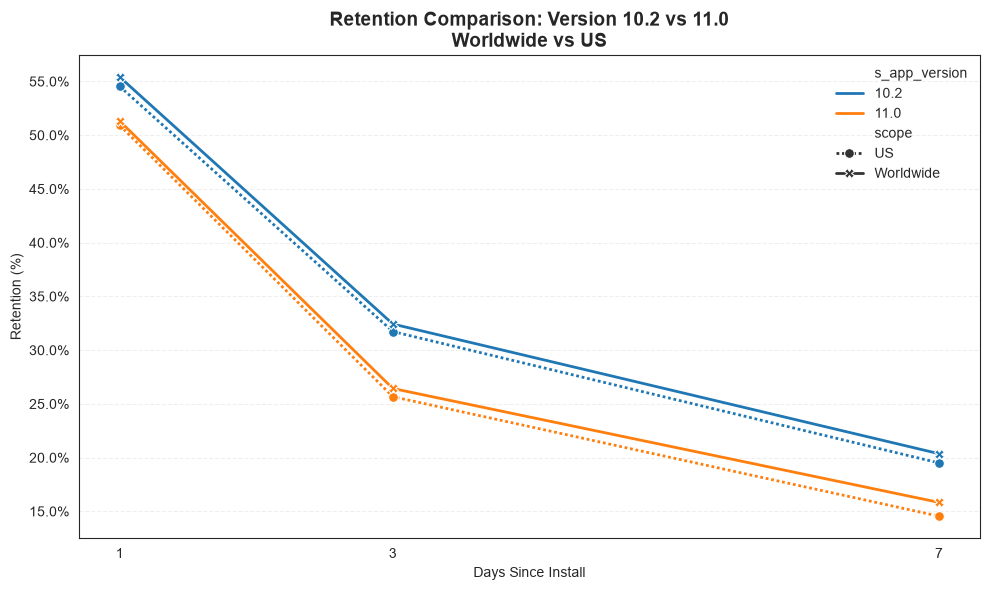

In [31]:
plt.figure(figsize=(10,6))
sns.lineplot(
    data=retention,
    x="i_cohort_groups",
    y="retention %",
    hue="s_app_version",     
    style="scope",            
    markers=True,
    dashes={
        "Worldwide": "",
        "US": (1,1)
    },
    linewidth=2,
    markersize=7
)
plt.title(
    "Retention Comparison: Version 10.2 vs 11.0\nWorldwide vs US",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Days Since Install")
plt.ylabel("Retention (%)")

plt.xticks([1,3,7])

plt.gca().yaxis.set_major_formatter(
    mtick.PercentFormatter()
)
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)
plt.legend(
    loc="upper right",
    frameon=False
)
plt.tight_layout()
plt.savefig('Retention_Comparison.png')
plt.show()

In [32]:
#Create level metrics View
con.sql("""
CREATE OR REPLACE Table level_metrics AS
SELECT
d_install_date,
s_app_version,
s_country,
s_acquisition_network,
s_installing_pckg_group,
i_cohort_groups,
i_level,
SUM(i_users) AS users,
SUM(i_level_started) AS starts,
SUM(i_level_completed) AS completions,
SUM(i_level_failed) AS failures,
SUM(f_play_time) AS playtime
FROM progression
WHERE s_app_version IN ('10.2','11.0')
GROUP BY ALL
""")

In [33]:
#Creating View level gold with calculated KPIs
con.sql("""
CREATE OR REPLACE VIEW level_Gold AS
SELECT
*,
completions::DOUBLE/starts
AS completion_rate,
failures/starts
AS failure_rate,
starts/users
AS attempts_per_user,
playtime/users
AS playtime_per_user
FROM level_metrics
""")

In [34]:
#Calculating playtime per level
playtime = con.sql("""
SELECT
s_app_version,
AVG(playtime_per_user) AS avg_playtime_per_level
FROM level_Gold
GROUP BY s_app_version
ORDER BY s_app_version
""").df()

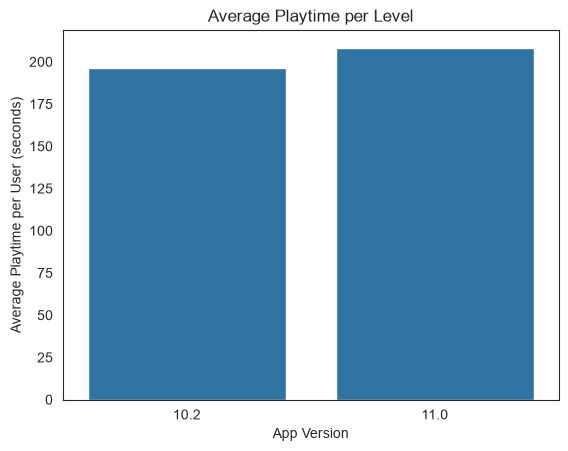

In [38]:
#Plotting overall playtime per level
sns.barplot(
    data=playtime,
    x="s_app_version",
    y="avg_playtime_per_level"
)
plt.title("Average Playtime per Level")
plt.xlabel("App Version")
plt.ylabel("Average Playtime per User (seconds)")
plt.savefig('Average_Playtime_per_Level.png')
plt.show()

In [36]:
#Calculating failure rate per level per version
failure = con.sql("""
SELECT
s_app_version,
i_level,
AVG(failure_rate) AS failure_rate
FROM level_Gold
GROUP BY
s_app_version,
i_level
ORDER BY
i_level,
s_app_version
""").df()

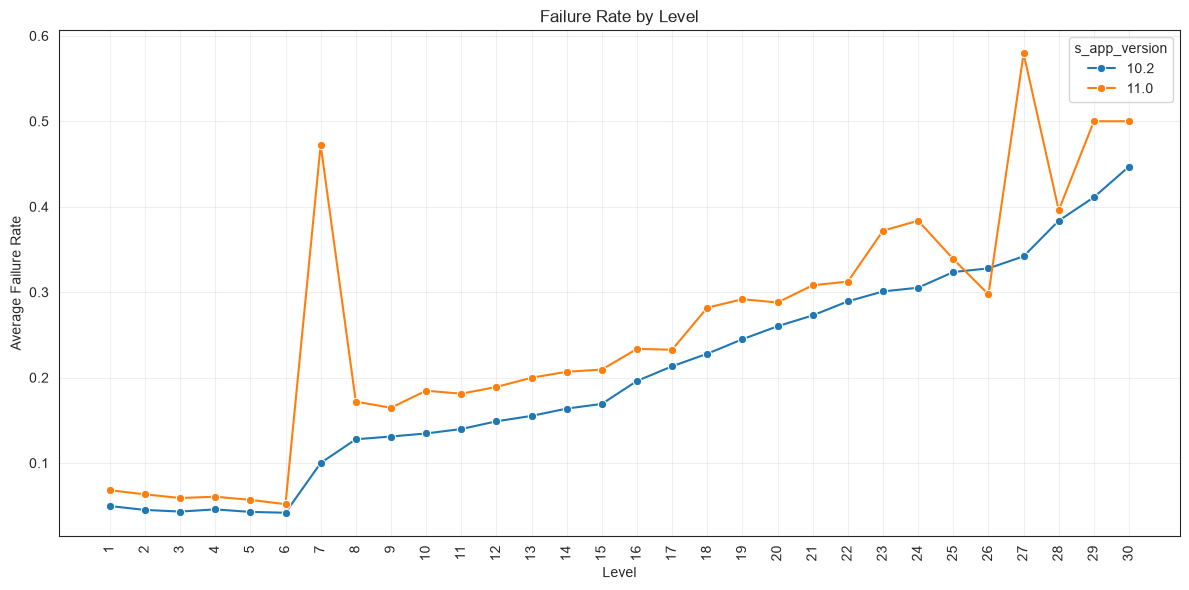

In [40]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=failure,
    x="i_level",
    y="failure_rate",
    hue="s_app_version",
    marker="o"
)

plt.title("Failure Rate by Level")
plt.xlabel("Level")
plt.ylabel("Average Failure Rate")

# Show every level as an x-axis tick
plt.xticks(
    ticks=sorted(failure["i_level"].unique()),
    rotation=90
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    'Failure_Rate_by_Level.png'
)
plt.show()